In [17]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import scipy.stats as stats
import matplotlib.pyplot as plt

import os
os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
#os.chdir(r"E:\academy\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")

print(os.getcwd())

G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


### 1. Create event binary matrix (Index-dates, columns station)

In [18]:
gauge_final=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv')
gauge_final.set_index('GaugeID',inplace=True)

dates=pd.date_range(start='1950',end='2021',freq='D')
binary_matrix=pd.DataFrame(np.nan,index=dates,columns=gauge_final.index.values)

for stn in gauge_final.index.values:
    flood_events=pd.read_csv(f'3_Data/Data_p/5_flood events/independent/{stn}.csv')
    binary_matrix.loc[flood_events['Peak Date'],stn]=1

# Calculate ES matrix
ES_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
binary_matrix



,IWM-gauge-17,IWM-gauge-27,IWM-gauge-29,IWM-gauge-32,IWM-gauge-36,IWM-gauge-40,IWM-gauge-54,IWM-gauge-57,IWM-gauge-60,IWM-gauge-68,...,IWM-gauge-995,IWM-gauge-996,IWM-gauge-997,IWM-gauge-999,IWM-gauge-1000,IWM-gauge-1001,IWM-gauge-1004,IWM-gauge-1006,IWM-gauge-1078,IWM-gauge-1103
1950-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2 ES algorithm - Method 1

In [19]:
import itertools
import pandas as pd


combinations = list(itertools.product(gauge_final.index.values, gauge_final.index.values))
df = pd.DataFrame(combinations, columns=["x", "y"])

In [7]:

tau=20
for i in range(len(df)):
    #Clip the common dates
    x=df['x'][i]
    y=df['y'][i]
    clip_st=gauge_final.loc[[x,y],'Start_date'].max()
    clip_end=gauge_final.loc[[x,y],'End_date'].min()
    binary_matrix_clip=binary_matrix.loc[clip_st:clip_end]


    # 1. X synchronization on Y
    event_x=binary_matrix_clip[binary_matrix_clip[x]==1].copy()
    df.loc[i,'sum_x']=event_x[x].sum()

    date_window = sorted(set([d + pd.Timedelta(days=i) for d in event_x.index for i in range(0, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    xy_forward=binary_matrix.loc[datetime_index,:]

    date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_x.index for i in range(1, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    xy_backward=binary_matrix.loc[datetime_index,:]

    df.loc[i,'S_xy']=xy_forward[y].sum()+xy_backward[y].sum()


    # 2. Y Synchronization on X
    event_y=binary_matrix_clip[binary_matrix_clip[y]==1].copy()
    df.loc[i,'sum_y']=event_y[y].sum()

    date_window = sorted(set([d + pd.Timedelta(days=i) for d in event_y.index for i in range(0, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    yx_forward=binary_matrix.loc[datetime_index,:]

    date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_y.index for i in range(1, tau)])) # Set helps to store only unique date
    datetime_index = pd.DatetimeIndex(date_window)
    yx_backward=binary_matrix.loc[datetime_index,:]

    df.loc[i,'S_yx']=yx_forward[x].sum()+yx_backward[x].sum()



    # Total synchornization
    df.loc[i,'ES']=(df.loc[i,'S_xy']+df.loc[i,'S_yx'])/(df.loc[i,'sum_x']+df.loc[i,'sum_y'])

    #Directionality
    df.loc[i,'Directionality']=(xy_forward[y].sum()-yx_forward[x].sum())/(xy_forward[y].sum()+yx_forward[x].sum())

    
    delay=[]
    for x_date in event_x.index:
        date_window = sorted(set([x_date + pd.Timedelta(days=i) for i in range(1 - tau, tau)]))
        
        events=binary_matrix.loc[pd.DatetimeIndex(date_window),:]
        y_date=events[events[y]==1].index
        
        if pd.notna(y_date.mean()):
            delay.append((y_date.mean() - x_date).days)  # sometime more than one event of y will come in the window, so take mean

    # Compute the average delay
    df.loc[i, "Delay"] = np.mean(delay)


df.to_csv(r"2_Analysis\3_Spatial connectivity\Outputs\ES_result1.csv")

C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_1692\39024133.py:46: RuntimeWarning: invalid value encountered in scalar divide
  df.loc[i,'Directionality']=(xy_forward[y].sum()-yx_forward[x].sum())/(xy_forward[y].sum()+yx_forward[x].sum())
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_1692\39024133.py:46: RuntimeWarning: invalid value encountered in scalar divide
  df.loc[i,'Directionality']=(xy_forward[y].sum()-yx_forward[x].sum())/(xy_forward[y].sum()+yx_forward[x].sum())
c:\Users\2024CEZ8029\anaconda3\envs\imed\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(

In [20]:
## # Calculate ES matrix
gauge_final=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv')
gauge_final.set_index('GaugeID',inplace=True)

df=pd.read_csv(r"2_Analysis\3_Spatial connectivity\Outputs\ES_result1.csv")
ES_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
Delay_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
Direction_matrix=pd.DataFrame(np.nan,index=gauge_final.index.values,columns=gauge_final.index.values)
for i in range(len(df)):
    
    ES_matrix.loc[df.loc[i,'x'],df.loc[i,'y']]=df.loc[i,'ES']
    Direction_matrix.loc[df.loc[i,'x'],df.loc[i,'y']]=df.loc[i,'Directionality']
    Delay_matrix.loc[df.loc[i,'x'],df.loc[i,'y']]=df.loc[i,'Delay']
    

#### Repair works

In [228]:
i=1;j=0
x=gauge_final['GaugeID'][i]
y=gauge_final['GaugeID'][j]

#Clip the common dates
clip_st=gauge_final.loc[[i,j],'Start_date'].max()
clip_end=gauge_final.loc[[i,j],'End_date'].min()
binary_matrix_clip=binary_matrix.loc[clip_st:clip_end]


event_x=binary_matrix_clip[binary_matrix_clip[x]==1].copy()
sum_x=event_x[x].sum()
date_window = sorted(set([d - pd.Timedelta(days=i) for d in event_x.index for i in range(0, tau)])) # Set helps to store only unique date
datetime_index = pd.DatetimeIndex(date_window)


xy_sync_events=binary_matrix.loc[datetime_index,:]  # Here we shouldnt use binary_matrix_clip. Bcoz it will creaete problem when an event comes at last date

xy_sync_events[y].sum()/sum_x

sum_x


206.0

# PLOTs

### 1. Graph plot

In [21]:
data=gauge_final
data['strength']=ES_matrix.mean(axis=1)
stations=data.index.values


FileNotFoundError: [Errno 2] No such file or directory: '3_Spatial connectivity/ss.jpeg'

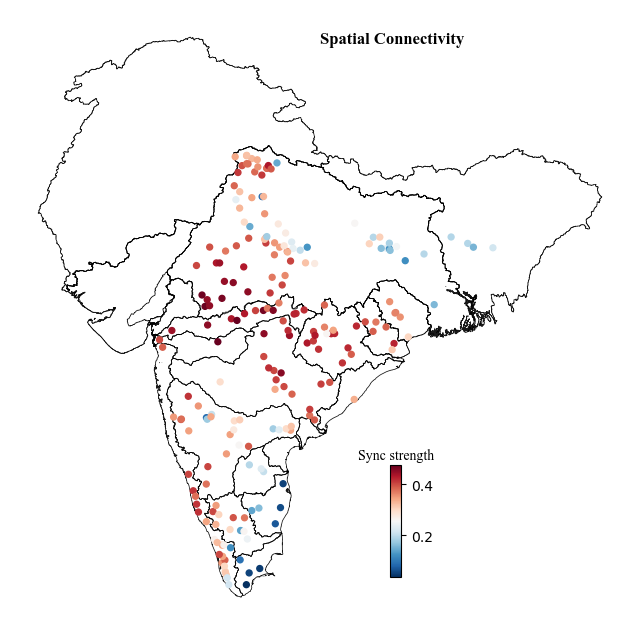

In [29]:
import matplotlib.colors as mcolors

south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

fig, ax1 = plt.subplots(1, 1, figsize=(8,8), subplot_kw={"projection": ccrs.PlateCarree()})
south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

#Axis setting
[x.set_visible(False) for x in ax1.spines.values()]
[x.set_linewidth(0.2) for x in ax1.spines.values()]



# Edges
c1=np.repeat(['Blue'],len(data['Latitude']))
# Define color map for edges
cmap = mcolors.LinearSegmentedColormap.from_list("delay_cmap", ["blue", "green", "red"])  # Blue (neg), Gray (0), Red (pos)
norm = plt.Normalize(vmin=0, vmax=2)  # Normalize delay values for color mapping


threshold = 0.6# Define threshold for strong synchronization
for stn1 in stations:
    for stn2 in stations:
        if stn1 != stn2 and ES_matrix.loc[stn1, stn2] > threshold:
            lon1, lat1 = data.loc[stn1,['Longitude','Latitude']]
            lon2, lat2 = data.loc[stn2,['Longitude','Latitude']]

            delay = Delay_matrix.loc[stn1, stn2]
            edge_color = cmap(norm(delay))
            ax1.plot([lon1, lon2], [lat1, lat2], color=edge_color, linewidth=0.4, alpha=0.6)

sc=ax1.scatter(data['Longitude'],data['Latitude'],c=data['strength'],cmap='RdBu_r',s=18,edgecolor=None)

ax1.text(0.50, 0.95, f'Spatial Connectivity', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
transform=ax1.transAxes, ha='left', va='center')


cbar_ax = fig.add_axes([0.6, 0.17, 0.014, 0.14])
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.ax.set_xlabel('Sync strength', fontsize=10, fontname='Times New Roman')
cbar.ax.xaxis.set_label_position('top')
#cbar.ax.xaxis.set_ticks_position('top')
#plt.savefig(fr'3_Spatial connectivity\Outputs\spatial_connect.png', bbox_inches='tight',dpi=1000)
plt.savefig(fr"3_Spatial connectivity/ss.jpeg", bbox_inches='tight',dpi=200)

## 3 GIF

In [26]:
stn1

'IWM-gauge-27'

In [ ]:
import matplotlib.colors as mcolors

south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')




threshold = 0.6# Define threshold for strong synchronization
for stn1 in stations:
    
    fig, ax1 = plt.subplots(1, 1, figsize=(8,8), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]



    # Edges
    c1=np.repeat(['Blue'],len(data['Latitude']))
    # Define color map for edges
    cmap = mcolors.LinearSegmentedColormap.from_list("delay_cmap", ["blue", "green", "red"])  # Blue (neg), Gray (0), Red (pos)
    norm = plt.Normalize(vmin=0, vmax=2)  # Normalize delay values for color mapping

    for stn2 in stations:
        if stn1 != stn2 and ES_matrix.loc[stn1, stn2] > threshold:
            lon1, lat1 = data.loc[stn1,['Longitude','Latitude']]
            lon2, lat2 = data.loc[stn2,['Longitude','Latitude']]

            delay = Delay_matrix.loc[stn1, stn2]
            edge_color = cmap(norm(delay))
            ax1.plot([lon1, lon2], [lat1, lat2], color=edge_color, linewidth=0.4, alpha=0.6)
            

    sc1=ax1.scatter(data['Longitude'],data['Latitude'],c=data['strength'],cmap='RdBu_r',s=14,edgecolor=None,alpha=0.4)       
    sc2=ax1.scatter(data.loc[stn1,'Longitude'],data.loc[stn1,'Latitude'],c=data.loc[stn1,'strength'],cmap='RdBu_r',s=20,edgecolor=None)
    ax1.text(0.50, 0.95, f'Spatial Connectivity', fontsize=12, color='black',fontname='Times New Roman',weight='bold',transform=ax1.transAxes, ha='left', va='center')


    cbar_ax = fig.add_axes([0.6, 0.17, 0.014, 0.14])
    cbar = plt.colorbar(sc1, cax=cbar_ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.ax.set_xlabel('Sync strength', fontsize=10, fontname='Times New Roman')
    cbar.ax.xaxis.set_label_position('top')
    
    plt.savefig(fr"2_Analysis/3_Spatial connectivity/Outputs/Plots_gif/{stn1[10:]}.png", bbox_inches='tight',dpi=200)
    plt.close(fig) 

#cbar.ax.xaxis.set_ticks_position('top')
#plt.savefig(fr'2_Analysis\0_Datapreprocessing\Outputs\{condition}', bbox_inches='tight',dpi=1000)

'158'

In [ ]:
import imageio


images = [imageio.imread(fr"2_Analysis/3_Spatial connectivity/Outputs/{stn[10:]}.png") for stn in stations]
imageio.mimsave('2_Analysis/3_Spatial connectivity/Outputs/Plots_gif/gif.gif', images,duration=0.1)

C:\Users\2024CEZ8029\AppData\Local\Temp\ipykernel_8272\691705676.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(fr"2_Analysis/3_Spatial connectivity/Outputs/{stn[10:]}.png") for stn in stations]


In [19]:
data.loc[[stn1,stn2],'Longitude']

GaugeID
IWM-gauge-1103    89.3236
IWM-gauge-1103    89.3236
Name: Longitude, dtype: float64